# Reconstruction example

We use GP to reconstruct two functions $f(x)$ and $g(x)$ and use these reconstruction to build the derived function

$$D(x) = (1+x)\,g'(x)/f(x)$$

In [1]:
import sys,os
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from reconstruction_tools.GaussianProcess import GPCalculator

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
def get_theory(coeffs):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(coeffs)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}
    return results

# 1) Create data

## Generating correlated data

In [3]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

In [4]:
fiducial_func1 = {'a0': 3,
                  'a1': -1,
                  'a2': 5,
                  'a3': -0.1}

theory_model_func1 = get_theory(list(fiducial_func1.values()))

fiducial_func2 = {'a0': 0,
                  'a1': 1,
                  'a2': -2,
                  'a3':0.5}

theory_model_func2 = get_theory(list(fiducial_func2.values()))

In [5]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals_1 = theory_model_func1['f'](dataset['x'])
errors = abs(thvals_1)*err_fac/100
dataset['f1_err'] = errors

thvals_2 = theory_model_func2['f'](dataset['x'])
errors = abs(thvals_2)*err_fac/100
dataset['f2_err'] = errors

dataset['r(f1,f2)'] = np.random.uniform(0,1.,len(dataset))

In [6]:
covmat_func1 = pd.DataFrame(np.diag(errors*2),columns=['f1_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_func1.index = covmat_func1.columns

covmat_func2 = pd.DataFrame(np.diag(errors*2),columns=['f2_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_func2.index = covmat_func2.columns

cov_cross = np.diag([row['f1_err']*row['f2_err']*row['r(f1,f2)'] for ind,row in dataset.iterrows()])

joint_matrix = np.block([[covmat_func1.values,  cov_cross],
                         [cov_cross.T, covmat_func2.values]])

N = len(dataset)
labels = [f"f1_{i}" for i in range(N)] + [f"f2_{i}" for i in range(N)]
data_covmat = pd.DataFrame(joint_matrix, columns=labels, index=labels)

In [7]:
obsvec = np.random.multivariate_normal([v for v in thvals_1]+[v for v in thvals_2],data_covmat.values)

dataset['f1'] = obsvec[:len(dataset)]
dataset['f2'] = obsvec[len(dataset):]

dataset = dataset[['x','f1','f2','f1_err','f2_err']]

dataset

,x,f1,f2,f1_err,f2_err
0,1.469299,12.457997,-1.124090,0.600385,0.063119
1,1.878478,17.323479,-2.197952,0.905104,0.093230
2,1.116126,8.124893,-0.638336,0.398676,0.034007
3,0.481709,3.731788,0.182866,0.183367,0.003676
4,1.811973,17.667730,-1.702930,0.850467,0.088997
5,0.602550,4.183912,-0.026256,0.209545,0.000710
6,0.624868,4.277355,-0.032231,0.215152,0.001703
7,1.665164,14.892844,-1.568024,0.736849,0.078591
8,0.017043,2.990914,0.004592,0.149220,0.000823
9,1.461109,12.170550,-1.413288,0.595058,0.062448


## Plot data

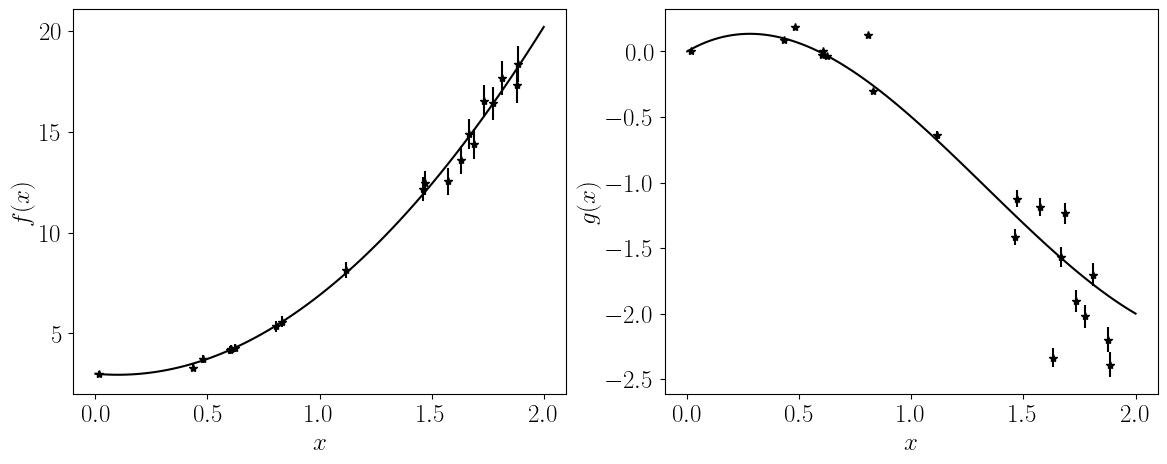

In [9]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(14,5))
axes[0].plot(xplot,theory_model_func1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f(x)$')

axes[1].plot(xplot,theory_model_func2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$g(x)$');

# 2) Observable reconstruction

## Settings

In [10]:
N_recon = 5
xmin_recon = 0.1
xmax_recon = 1.8
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

possible_derivatives = ['f','int','d1','d2']

kernel = 'RBF'

method = 'BAYESIAN'

## Reconstructions

In [11]:
all_reconstructions = {}

## Correlated

In [12]:
gp = GPCalculator(dataset,data_covmat,kernel_type=kernel)

In [13]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)

all_reconstructions['correlated'] = {'means': means,
                                     'covmat': joint_cov,
                                     'color': red}

print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

Removed no burn in
GP (BAYESIAN) done in 296.66 s


## Uncorrelated

In [14]:
dataset_func1 = pd.DataFrame({'x': dataset['x'].values,
                              'f': dataset['f1'].values,
                              'f_err': dataset['f1_err'].values})

gp = GPCalculator(dataset_func1,covmat_func1,kernel_type=kernel)

tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)

all_reconstructions['fx'] = {'means': means,
                             'covmat': joint_cov,
                             'color': yellow}

print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

Removed no burn in
GP (BAYESIAN) done in 324.36 s


In [15]:
dataset_func2 = pd.DataFrame({'x': dataset['x'].values,
                              'f': dataset['f2'].values,
                              'f_err': dataset['f2_err'].values})

gp = GPCalculator(dataset_func2,covmat_func2,kernel_type=kernel)

tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)

all_reconstructions['gx'] = {'means': means,
                             'covmat': joint_cov,
                             'color': yellow}

print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

Removed no burn in
GP (BAYESIAN) done in 277.21 s


### Plot reconstruction

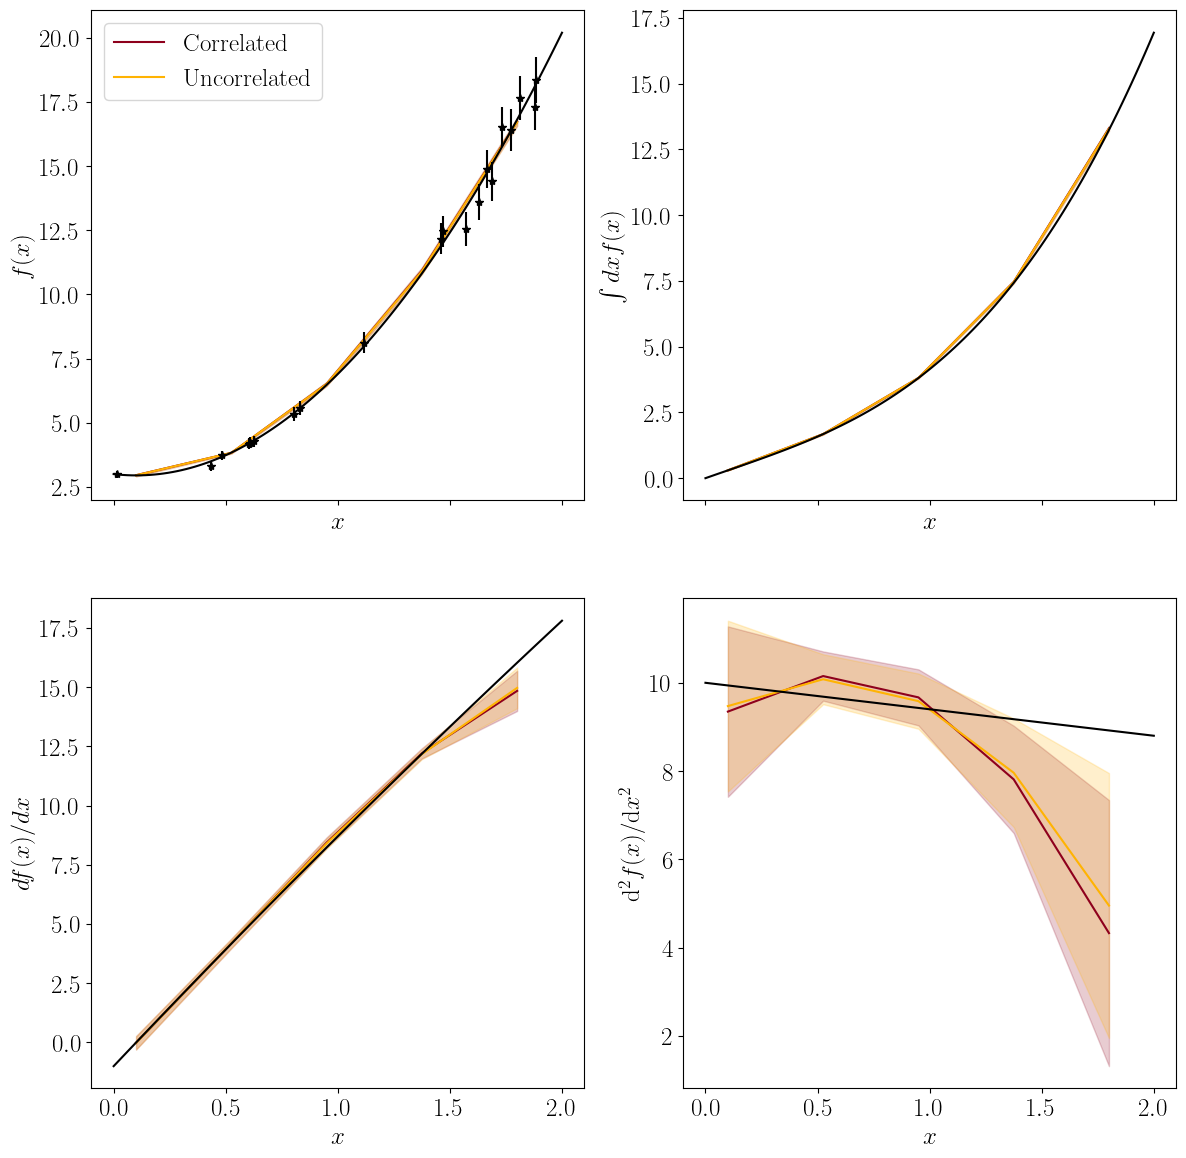

In [18]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = r'$f(x)$'
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int dx f(x)$'
    elif ind == 2:
        i = 1
        j = 0
        label = r'$df(x)/dx$'
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2f(x)$'+'/d'+r'$x^2$'

    df = all_reconstructions['correlated']['means']
    axes[i,j].fill_between(df['x'],df[deriv+'1']+df[deriv+'1_err'],df[deriv+'1']-df[deriv+'1_err'],alpha=0.2,
                           color=all_reconstructions['correlated']['color'])
    axes[i,j].plot(df['x'],df[deriv+'1'],color=all_reconstructions['correlated']['color'],label='Correlated')
    
    df = all_reconstructions['fx']['means']
    axes[i,j].fill_between(df['x'],df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2,
                            color=all_reconstructions['fx']['color'])
    axes[i,j].plot(df['x'],df[deriv],color=all_reconstructions['fx']['color'],label='Uncorrelated')
    
    axes[i,j].plot(xplot,theory_model_func1[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv+'1'],yerr=dataset[deriv+'1_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(r'$x$')
    axes[i,j].set_ylabel(label)
    axes[0,0].legend(loc='best')

In [ ]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = r'$g(x)$'
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int dx g(x)$'
    elif ind == 2:
        i = 1
        j = 0
        label = r'$dg(x)/dx$'
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2g(x)$'+'/d'+r'$x^2$'

    df = all_reconstructions['correlated']['means']
    axes[i,j].fill_between(df['x'],df[deriv+'2']+df[deriv+'2_err'],df[deriv+'2']-df[deriv+'2_err'],alpha=0.2)
    axes[i,j].plot(df['x'],df[deriv+'2'],color=all_reconstructions['correlated']['color'],label='Correlated')
    
    df = all_reconstructions['gx']['means']
    axes[i,j].fill_between(df['x'],df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    axes[i,j].plot(df['x'],df[deriv],color=all_reconstructions['fx']['color'],label='Uncorrelated')
    
    axes[i,j].plot(xplot,theory_model_func2(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv+'2'],yerr=dataset[deriv+'2_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(r'$x$')
    axes[i,j].set_ylabel(label)
    axes[0,0].legend(loc='best')

# 3) Obtain derived function

$$D(x)=g'(x)/f(x)$$

In [ ]:
from derived_function.reconstructor import DerivedFunction

In [ ]:
fiducial_primary = {'fx_f_{}'.format(ind): theory_model_func1(x)['f'] for ind,x in enumerate(x_recon)}
fiducial_primary = fiducial_primary | {'gx_d1_{}'.format(ind): theory_model_func2(x)['d1'] for ind,x in enumerate(x_recon)}

In [ ]:
fiducial_recon = {'D_{}'.format(ind): (1+x_recon[ind])*theory_model_func2(x_recon[ind])['d1']/theory_model_func1(x_recon[ind])['f'] 
                  for ind in range(N_recon)}

## Sampling

In [ ]:
method_dict = {'type': 'sampling',
               'options': {'sampler': 'Nautilus',
                           'run_options': 'poor'}}

In [ ]:
results = {}

### Run correlated reconstruction

In [ ]:
recon_dict = {'funcs': all_reconstructions['correlated']['means']}
cov_dict   = {'funcs': all_reconstructions['correlated']['covmat']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,funcs_f1,funcs_d12: (1+x)*funcs_d12/funcs_f1
derived_name  = 'D'

results['Correlated'] = {'sample': reconstructor.run(derived_logic,derived_name,sigma_width=5),
                         'color': red}

### Run uncorrelated reconstruction

In [ ]:
recon_dict = {k: v['means'] for k,v in all_reconstructions.items() if k in ['fx','gx']}
cov_dict   = {k: v['covmat'] for k,v in all_reconstructions.items() if k in ['fx','gx']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,fx_f,gx_d1: (1+x)*gx_d1/fx_f
derived_name  = 'D'

results['Uncorrelated'] = {'sample': reconstructor.run(derived_logic,derived_name,sigma_width=5),
                           'color': yellow}

### Plotting parameters

**Primary**

In [ ]:
#g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
#
#g.settings.figure_legend_frame = False
#g.settings.axes_fontsize=20
#g.settings.axes_labelsize=20
#g.settings.legend_fontsize=20
#g.settings.axis_marker_color = 'black'
#g.settings.axis_marker_ls = '--'
#g.settings.axis_marker_lw = 1
#g.settings.axis_tick_x_rotation = 45
#g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_primary.keys()),
#                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
#                legend_labels=list(results.keys()),
#                markers=fiducial_primary
#               )
#g.fig.align_ylabels()
#g.fig.align_xlabels();

**Derived**

In [ ]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Plotting reconstructed function

In [ ]:
for method in ['Correlated','Uncorrelated']:
    sample = results[method]['sample']
    results[method]['reconstruction'] = pd.DataFrame({'x': x_recon})
    results[method]['reconstruction']['value'] = sample.getMeans()[2*N_recon:]
    results[method]['reconstruction']['error'] = np.sqrt(sample.getVars()[2*N_recon:])

In [ ]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in ['Correlated','Uncorrelated']:
    reconstruction = results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
plt.plot(xplot,(1+xplot)*theory_model_func2(xplot)['d1']/theory_model_func1(xplot)['f'],color='black',label='Theory')
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');

### Realizations method

In [ ]:
method_dict = {'type': 'realizations',
               'options': {'Nreals': 1000,
                           'Nsamples': 10000}}

In [ ]:
real_results = {}

### Correlated

In [ ]:
recon_dict = {'funcs': all_reconstructions['correlated']['means']}
cov_dict   = {'funcs': all_reconstructions['correlated']['covmat']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,funcs_f1,funcs_d12: (1+x)*funcs_d12/funcs_f1
derived_name  = 'D'

real_results['Correlated'] = {'sample': reconstructor.run(derived_logic,derived_name),
                              'color': red}

### Uncorrelated

In [ ]:
recon_dict = {k: v['means'] for k,v in all_reconstructions.items() if k in ['fx','gx']}
cov_dict   = {k: v['covmat'] for k,v in all_reconstructions.items() if k in ['fx','gx']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,fx_f,gx_d1: (1+x)*gx_d1/fx_f
derived_name  = 'D'

real_results['Uncorrelated'] = {'sample': reconstructor.run(derived_logic,derived_name),
                                'color': yellow}

In [ ]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in real_results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in real_results.values()],
                legend_labels=list(real_results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

In [ ]:
for method in ['Correlated','Uncorrelated']:
    sample = real_results[method]['sample']
    real_results[method]['reconstruction'] = pd.DataFrame({'x': x_recon}) #generilize!!!!
    real_results[method]['reconstruction']['value'] = sample.getMeans()
    real_results[method]['reconstruction']['error'] = np.sqrt(sample.getVars())

In [ ]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in ['Correlated','Uncorrelated']:
    reconstruction = real_results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=real_results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=real_results[method]['color'],label=method)
plt.plot(xplot,(1+xplot)*theory_model_func2(xplot)['d1']/theory_model_func1(xplot)['f'],color='black',label='Theory')
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');

## Method comparison

In [ ]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=1,ncols=2,sharey=True,sharex=True,figsize=(14,5))

axes[0].set_title('Sampling method')
axes[1].set_title('Realizations method')

for method in ['Correlated','Uncorrelated']:
    reconstruction = results[method]['reconstruction']
    axes[0].fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                         reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    axes[0].plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
    
    reconstruction = real_results[method]['reconstruction']
    axes[1].fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                         reconstruction['value']-reconstruction['error'],alpha=0.2,color=real_results[method]['color'])
    axes[1].plot(reconstruction['x'],reconstruction['value'],lw=2,color=real_results[method]['color'],label=method)
axes[1].plot(xplot,(1+xplot)*theory_model_func2(xplot)['d1']/theory_model_func1(xplot)['f'],color='black',label='Theory')
axes[1].set_xlabel(r'$x$')
axes[0].plot(xplot,(1+xplot)*theory_model_func2(xplot)['d1']/theory_model_func1(xplot)['f'],color='black',label='Theory')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$D(x)$')
axes[0].legend(loc='best');